Data Collection

In [3]:
queries = {
    "Agriculture": "farm",
    "Mining": "mining",
    "Manufacturing": "manufacturing",
    "Energy": "energy",
    "Construction": "construction",
    "Retail": "retail",
    "Information & Communication": "software",
    "Finance": "finance",
    "Real Estate": "property",
    "Professional Services": "consulting"
}

In [4]:
import requests
import time
import random
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("COMPANIES_HOUSE_API_KEY")

def get_with_retry(url, auth, max_retries=5):
    """GET request with exponential backoff + jitter on 429 responses."""
    for attempt in range(max_retries):
        response = requests.get(url, auth=auth)

        if response.status_code != 429:
            return response

        base_wait = 2 ** attempt
        jitter = random.uniform(0, base_wait)
        wait = base_wait + jitter
        print(f"429 rate limited. Retrying in {wait:.1f}s (attempt {attempt + 1}/{max_retries})")
        time.sleep(wait)

    return response

if os.path.exists("data/company_numbers.csv"):
    company_numbers = pd.read_csv("data/company_numbers.csv")["company_number"].tolist()
    print(f"Loaded {len(company_numbers)} companies from CSV")
else:
    company_numbers = set()

    for industry, query in queries.items():

        print(f"\nCollecting for: {industry}")

        start_index = 0

        while start_index < 200:

            url = f"https://api.company-information.service.gov.uk/search/companies?q={query}&items_per_page=50&start_index={start_index}"

            response = get_with_retry(url, auth=(API_KEY, ""))

            if response.status_code != 200:
                break

            data = response.json()

            for item in data.get("items", []):
                number = item.get("company_number")
                if number:
                    company_numbers.add(number)

            start_index += 50
            time.sleep(0.5)

    company_numbers = list(company_numbers)
    pd.DataFrame({"company_number": company_numbers}).to_csv("data/company_numbers.csv", index=False)
    print("Total companies collected:", len(company_numbers))











Total companies collected: 0


In [5]:
if os.path.exists("data/companies_raw.csv"):
    company_data = pd.read_csv("data/companies_raw.csv").to_dict("records")
    print(f"Loaded {len(company_data)} companies from CSV")
else:
    company_data = []

    for i, company in enumerate(company_numbers):

        if i % 100 == 0:
            print(f"Company {i+1}/{len(company_numbers)}")

        url = f"https://api.company-information.service.gov.uk/company/{company}"

        response = get_with_retry(url, auth=(API_KEY, ""))

        if response.status_code == 200:

            data = response.json()

            company_data.append({
                "company_number": company,
                "sic_codes": data.get("sic_codes")
            })

        time.sleep(0.5)

    pd.DataFrame(company_data).to_csv("data/companies_raw.csv", index=False)
    print(f"Collected and saved {len(company_data)} companies")

Loaded 1967 companies from CSV


In [6]:
if os.path.exists("data/directors_raw.csv"):
    officer_data = pd.read_csv("data/directors_raw.csv").to_dict("records")
    print(f"Loaded {len(officer_data)} officers from CSV")
else:
    officer_data = []

    for i, company in enumerate(company_numbers):

        if i % 100 == 0:
            print(f"Officers {i+1}/{len(company_numbers)}")

        url = f"https://api.company-information.service.gov.uk/company/{company}/officers"

        response = get_with_retry(url, auth=(API_KEY, ""))

        if response.status_code == 200:

            data = response.json()

            for officer in data.get("items", []):

                if officer.get("officer_role") == "director":

                    officer_data.append({
                        "company_number": company,
                        "name": officer.get("name"),
                        "nationality": officer.get("nationality")
                    })

        time.sleep(0.5)

    pd.DataFrame(officer_data).to_csv("data/directors_raw.csv", index=False)
    print(f"Collected and saved {len(officer_data)} officers")

Loaded 4651 officers from CSV


Data Joining

In [7]:
df_officers = pd.DataFrame(officer_data)
df_companies = pd.DataFrame(company_data)

In [8]:
df = df_officers.merge(df_companies, on="company_number", how="left")

Data Cleaning

In [9]:
print(f"Total director records: {len(df)}")
print(f"Null nationalities: {df['nationality'].isna().sum()}")
print(f"Unique raw values: {df['nationality'].nunique()}")
print()
print(df["nationality"].value_counts().to_string())


Total director records: 4651
Null nationalities: 1
Unique raw values: 117

nationality
British                                3534
English                                  92
Irish                                    88
American                                 69
Filipino                                 62
Romanian                                 56
German                                   55
French                                   53
Indian                                   45
Italian                                  45
Polish                                   38
Australian                               38
Pakistani                                33
Scottish                                 29
Spanish                                  24
South African                            24
Russian                                  19
Canadian                                 17
Hungarian                                15
Welsh                                    14
Belgian                          

In [10]:
# Lowercase and strip whitespace
df["nationality_normalized"] = df["nationality"].str.lower().str.strip()

# For multiple nationalities, take the first only
def split_compound(value):
    if pd.isna(value):
        return value
    for sep in [",", ";", "/", ", "]:
        if sep in value:
            return value.split(sep)[0].strip()
    return value

df["nationality_normalized"] = df["nationality_normalized"].apply(split_compound)


In [11]:
nationality_map = {
      "english": "british",
      "scottish": "british",
      "welsh": "british",
      "northern irish": "british",
      "united kingdom": "british",
      "uk": "british",
      "united states": "american",
      "usa": "american",
      "us": "american",
      "ireland": "irish",
      "netherlands": "dutch",
      "pakistan": "pakistani",
      "canada": "canadian",
      "cyprus": "cypriot",
      "venezuela": "venezuelan",
      "seychelles": "seychellois",
        }

df["nationality_clean"] = df["nationality_normalized"].map(nationality_map)

In [12]:
canonical = [
    "british", "irish", "american", "french", "german", "italian",
    "spanish", "polish", "romanian", "indian", "pakistani", "chinese",
    "australian", "canadian", "south african", "nigerian", "filipino",
    "dutch", "belgian", "hungarian", "russian", "ukrainian", "turkish",
    "brazilian", "japanese", "greek", "portuguese", "swedish", "danish",
    "norwegian", "finnish", "czech", "slovak", "bulgarian", "latvian",
    "lithuanian", "estonian", "austrian", "swiss", "egyptian", "moroccan",
    "algerian", "kenyan", "ghanaian", "zimbabwean", "bangladeshi",
    "sri lankan", "malaysian", "malawian", "cypriot", "lebanese", "israeli",
    "iranian", "iraqi", "saudi arabian", "emirati", "mexican",
    "chilean", "peruvian", "jamaican", "nepalese", "albanian",
    "new zealander", "jordanian", "senegalese", "ethiopian",
    "dominican", "guyanese", "gabonese", "sudanese", "afghan",
    "kazakh", "belizean", "luxembourger", "maltese", "yemeni",
    "singaporean", "thai", "korean", "taiwanese", "colombian",
    "argentine", "ecuadorian", "trinidadian", "barbadian",
  ]

In [13]:
from rapidfuzz import process, fuzz

# Only fuzzy match values that weren't handled by the nationality map
remaining = df.loc[df["nationality_clean"].isna(), "nationality_normalized"].dropna().unique()
print(f"Values to fuzzy match: {len(remaining)}")

fuzzy_map = {}
unmatched = []

for raw in remaining:
    # Exact match against canonical list (free check before fuzzy)
    if raw in canonical:
        fuzzy_map[raw] = raw
        continue

    result = process.extractOne(
        raw,
        canonical,
        scorer=fuzz.ratio,
        score_cutoff=80
    )

    if result:
        match, score, _ = result
        fuzzy_map[raw] = match
    else:
        unmatched.append(raw)


Values to fuzzy match: 88


In [14]:
# Show non-exact fuzzy matches for review
fuzzy_corrections = {k: v for k, v in fuzzy_map.items() if k != v}

print("Fuzzy corrections")
for raw, matched in sorted(fuzzy_corrections.items()):
    print(f"  {raw:40s} → {matched}")

print(f"\nUnmatched ({len(unmatched)}) ")
for val in sorted(unmatched):
    count = (df["nationality_normalized"] == val).sum()
    print(f"  {val:40s} ({count} rows)")


Fuzzy corrections
  austrialian                              → australian
  brittish                                 → british
  luxemburger                              → luxembourger
  ukranian                                 → ukrainian

Unmatched (9) 
  brisith                                  (1 rows)
  british (dual citizen south africa)      (1 rows)
  citizen of bosnia and herzegovina        (1 rows)
  citizen of seychelles                    (5 rows)
  citizen of vanuatu                       (1 rows)
  hong konger                              (1 rows)
  kittitian                                (1 rows)
  seychellois                              (1 rows)
  south african and ir                     (1 rows)


In [15]:
fuzzy_map_corrections = {
    # Misspelling that fuzzy missed (below threshold)
    "brisith": "british",

    # Descriptive formats
    "british (dual citizen south africa)": "british",
    "south african and ir": "south african",
    "citizen of bosnia and herzegovina": "bosnian",
    "citizen of seychelles": "seychellois",
    "citizen of vanuatu": "ni-vanuatu",

    # Genuine nationalities not in canonical list
    "hong konger": "hong konger",
    "kittitian": "kittitian",
    "seychellois": "seychellois",

    # Discard
    "other": "other",
}

fuzzy_map.update(fuzzy_map_corrections)
print(f"Added {len(fuzzy_map_corrections)} manual corrections")

Added 10 manual corrections


In [16]:
# Apply fuzzy map to fill remaining gaps
still_null = df["nationality_clean"].isna()
df.loc[still_null, "nationality_clean"] = df.loc[still_null, "nationality_normalized"].map(fuzzy_map)

# Anything still unmatched — keep the normalised value
still_null = df["nationality_clean"].isna()
df.loc[still_null, "nationality_clean"] = df.loc[still_null, "nationality_normalized"]

print(f"Null nationality_clean: {df['nationality_clean'].isna().sum()}")
print(f"Unique cleaned values: {df['nationality_clean'].nunique()}")
print()
print(df["nationality_clean"].value_counts().to_string())

Null nationality_clean: 1
Unique cleaned values: 80

nationality_clean
british          3699
irish              90
american           76
filipino           62
romanian           57
german             55
french             53
italian            47
indian             45
australian         41
polish             38
pakistani          34
south african      27
spanish            24
russian            19
canadian           18
hungarian          15
ukrainian          14
belgian            13
dutch              13
lithuanian         11
nigerian           10
chinese            10
danish              8
portuguese          8
seychellois         8
greek               8
egyptian            8
austrian            7
bulgarian           6
iranian             6
bangladeshi         6
swiss               6
moroccan            6
estonian            5
kenyan              5
cypriot             5
latvian             5
turkish             5
brazilian           4
swedish             4
japanese            4
norwe

Matching SIC codes to Industry

In [17]:
import ast

def get_first_sic(val):
    """Extract the first SIC code, handling both list and string-of-list from CSV."""
    if pd.isna(val):
        return None
    if isinstance(val, list):
        return val[0] if val else None
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list) and parsed:
            return parsed[0]
    except (ValueError, SyntaxError):
        return val
    return None

df["sic_code"] = df["sic_codes"].apply(get_first_sic)
df["sic_2"] = df["sic_code"].astype(str).str[:2]

In [18]:
sic_to_industry = {
    # Agriculture, Forestry and Fishing
    "01": "Agriculture", "02": "Agriculture", "03": "Agriculture",
    # Mining and Quarrying
    "05": "Mining", "06": "Mining", "07": "Mining", "08": "Mining", "09": "Mining",
    # Manufacturing (full range: 10-33)
    "10": "Manufacturing", "11": "Manufacturing", "12": "Manufacturing",
    "13": "Manufacturing", "14": "Manufacturing", "15": "Manufacturing",
    "16": "Manufacturing", "17": "Manufacturing", "18": "Manufacturing",
    "19": "Manufacturing", "20": "Manufacturing", "21": "Manufacturing",
    "22": "Manufacturing", "23": "Manufacturing", "24": "Manufacturing",
    "25": "Manufacturing", "26": "Manufacturing", "27": "Manufacturing",
    "28": "Manufacturing", "29": "Manufacturing", "30": "Manufacturing",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    # Energy
    "35": "Energy",
    # Water and Waste
    "36": "Water & Waste", "37": "Water & Waste", "38": "Water & Waste", "39": "Water & Waste",
    # Construction
    "41": "Construction", "42": "Construction", "43": "Construction",
    # Retail and Wholesale
    "45": "Retail", "46": "Retail", "47": "Retail",
    # Transport and Storage
    "49": "Transport", "50": "Transport", "51": "Transport", "52": "Transport", "53": "Transport",
    # Accommodation and Food
    "55": "Hospitality", "56": "Hospitality",
    # Information and Communication
    "58": "Information & Communication", "59": "Information & Communication",
    "60": "Information & Communication", "61": "Information & Communication",
    "62": "Information & Communication", "63": "Information & Communication",
    # Finance
    "64": "Finance", "65": "Finance", "66": "Finance",
    # Real Estate
    "68": "Real Estate",
    # Professional Services
    "69": "Professional Services", "70": "Professional Services",
    "71": "Professional Services", "72": "Professional Services",
    "73": "Professional Services", "74": "Professional Services",
    # Admin and Support
    "77": "Admin & Support", "78": "Admin & Support",
    "79": "Admin & Support", "80": "Admin & Support", "81": "Admin & Support", "82": "Admin & Support",
    # Education
    "85": "Education",
    # Health
    "86": "Health", "87": "Health", "88": "Health",
}

In [19]:
df["industry"] = df["sic_2"].map(sic_to_industry)
df["industry"] = df["industry"].fillna("Other")

In [20]:
df["industry"].value_counts()

# Question - are all industry groups present? 

industry
Professional Services          952
Other                          616
Information & Communication    581
Admin & Support                465
Retail                         392
Construction                   385
Finance                        332
Real Estate                    283
Manufacturing                  230
Mining                         125
Transport                       68
Education                       58
Hospitality                     56
Health                          37
Agriculture                     31
Energy                          28
Water & Waste                   12
Name: count, dtype: int64

Core analysis

In [21]:
df_non_british = df[df["nationality_clean"] != "british"]

In [22]:
top_nationalities = (
    df_non_british
    .groupby(["industry", "nationality_clean"])
    .size()
    .reset_index(name="count")
)

In [23]:
top_by_industry = (
    top_nationalities
    .sort_values(["industry", "count"], ascending=[True, False])
    .groupby("industry")
    .first()
    .reset_index()
)

Visualise

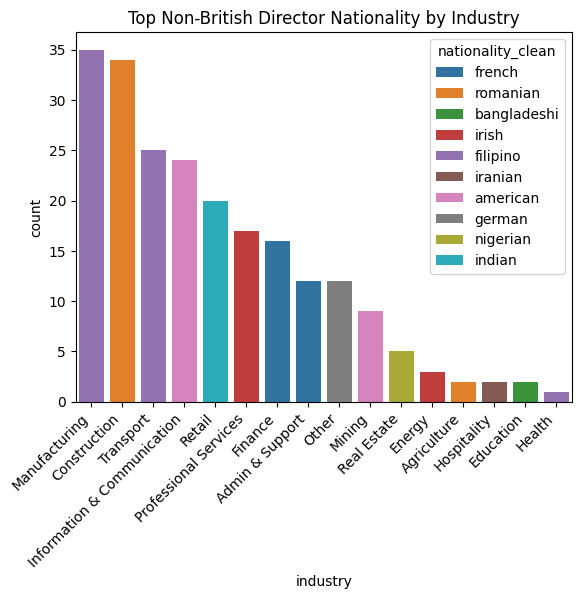

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

industry_order=top_by_industry.sort_values("count", ascending=False)["industry"]

sns.barplot(
    data=top_by_industry,
    x="industry",
    y="count",
    hue="nationality_clean",
    order=industry_order
)

plt.xticks(rotation=45, ha="right")
plt.title("Top Non-British Director Nationality by Industry")

plt.show()